In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.sparse import csr_matrix
from typing import Tuple

In [38]:
def load_and_clean_data(file_path: str):
    df = pd.read_csv('amazon_reviews.csv')
    df = df.dropna(subset=['Review Text'])
    df['Target'] = df['Rating'].apply(lambda x: 1 if x > 3 else 0)
    df_clean = df.copy()
    drop_cols = ['User Verified', 'Review Useful Count', 'Declaration Text']
    df_clean = df_clean.drop(columns=drop_cols, axis=1)
    print(f"Data loaded successfully. Shape: {df_clean.shape}")
    return df_clean

DATA_FILE = 'amazon_reviews.csv'
processed_df = load_and_clean_data(DATA_FILE)
processed_df.head()
    

Data loaded successfully. Shape: (6850, 8)


,Pageurl,Title,Review Text,Review Color,Review Date,Configuration Text,Rating,Target
0,https://www.amazon.com/All-New-Amazon-Echo-Dot...,Three Stars,Not great speakers,Black,10/3/2017,Echo Dot,3,0
1,https://www.amazon.com/All-New-Amazon-Echo-Dot...,Four Stars,Great little gagit,White,9/26/2017,Echo Dot,4,1
2,https://www.amazon.com/All-New-Amazon-Echo-Dot...,Awesome!,Awesome 👏🏽,White,9/8/2017,Echo Dot,5,1
3,https://www.amazon.com/All-New-Amazon-Echo-Dot...,Five Stars,Love my Echo,Black,10/19/2017,Echo Dot,5,1
4,https://www.amazon.com/All-New-Amazon-Echo-Dot...,Five Stars,Great device,Black,9/17/2017,Echo Dot,5,1


In [39]:
def prepare_features(df: pd.DataFrame) -> Tuple[csr_matrix, pd.Series, CountVectorizer]:
    print("Vectorizing text data...")
    vectorizer = CountVectorizer(stop_words='english', max_features=2500)
    
    X_vectorized = vectorizer.fit_transform(df['Review Text'])
    y = df['Target']
    
    return X_vectorized, y, vectorizer

X, y, text_vectorizer = prepare_features(processed_df)
print(f"X shape (Sparse Matrix): {X.shape}")

Vectorizing text data...
X shape (Sparse Matrix): (6850, 2500)


In [ ]:
def plot_project_visualizations(df: pd.DataFrame, y_test: pd.Series, y_pred: np.ndarray) -> None:
    %matplotlib inline
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
 
    print("Generating Class Distribution Plot...")
    sns.countplot(x='Target', data=df, ax=axes[0], palette='Blues_r')
    axes[0].set_title('1. Class Distribution (Imbalanced Data)', fontsize=14, fontweight='bold', pad=15)
    axes[0].set_xlabel('Review Sentiment', fontsize=12)
    axes[0].set_ylabel('Number of Reviews', fontsize=12)
    axes[0].set_xticklabels(['Negative (0-3 Stars)', 'Positive (4-5 Stars)'])
    
  
    print("Generating Confusion Matrix Heatmap...")
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False,
                annot_kws={'size': 14, 'weight': 'bold'})
    axes[1].set_title('2. Confusion Matrix Heatmap', fontsize=14, fontweight='bold', pad=15)
    axes[1].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('True Label', fontsize=12, fontweight='bold')
    axes[1].set_xticklabels(['Negative (0)', 'Positive (1)'])
    axes[1].set_yticklabels(['Negative (0)', 'Positive (1)'])
    
    plt.tight_layout()
    plt.show()

Splitting dataset into Train and Test sets (80/20)...
Training Multinomial Naive Bayes model...

Overall Accuracy: 88.32%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.67      0.72       300
           1       0.91      0.94      0.93      1070

    accuracy                           0.88      1370
   macro avg       0.84      0.81      0.82      1370
weighted avg       0.88      0.88      0.88      1370


[INFO] Generating Class Distribution Plot...
[INFO] Generating Confusion Matrix Heatmap...


C:\Users\ELMOSTAWRED\AppData\Local\Temp\ipykernel_15132\2325212813.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Target', data=df, ax=axes[0], palette='Blues_r')
C:\Users\ELMOSTAWRED\AppData\Local\Temp\ipykernel_15132\2325212813.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Negative (0-3 Stars)', 'Positive (4-5 Stars)'])


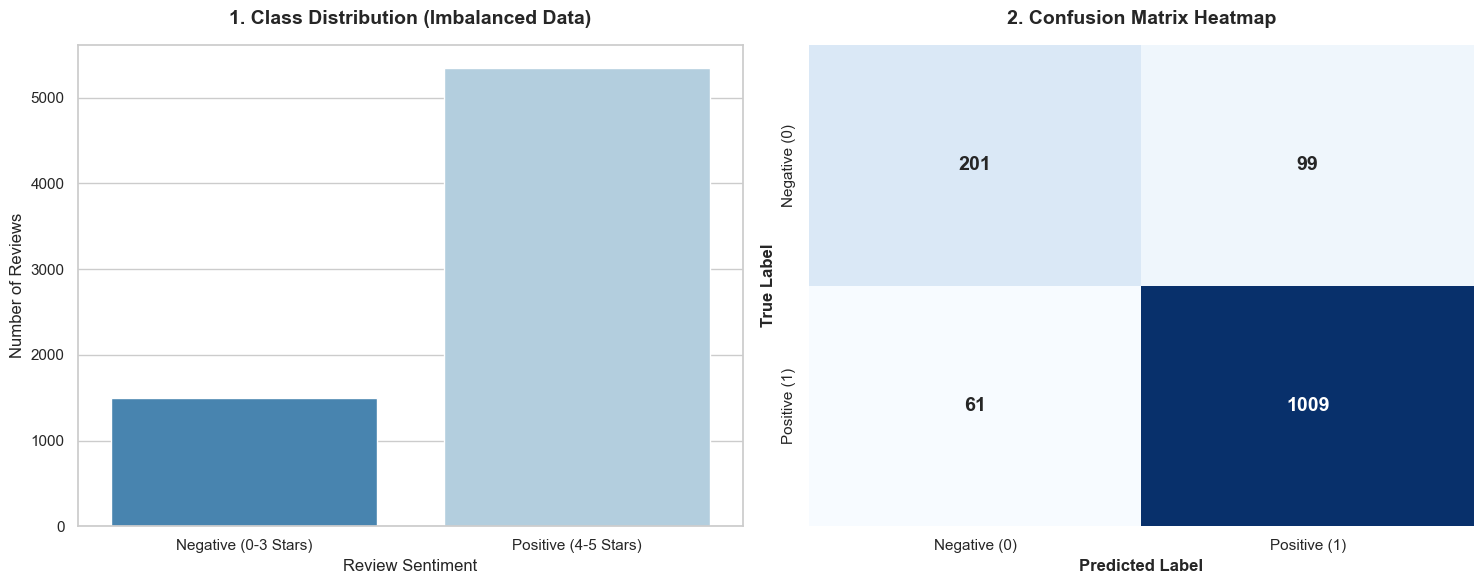

In [41]:
def train_and_evaluate_model(X: csr_matrix, y: pd.Series, df_for_plotting: pd.DataFrame) -> None:
    print("Splitting dataset into Train and Test sets (80/20)...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print("Training Multinomial Naive Bayes model...")
    model = MultinomialNB()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    print("\n" + "="*40)
    print(f"Overall Accuracy: {accuracy * 100:.2f}%\n")
    print("Detailed Classification Report:")
    print(classification_report(y_test, y_pred))
    print("="*40 + "\n")
    
  
    plot_project_visualizations(df_for_plotting, y_test, y_pred)

train_and_evaluate_model(X, y, processed_df)